In [16]:
import pandas as pd
from pathlib import Path

dest_dir = "../data/raw"

ratings = pd.read_csv(f"{dest_dir}/ratings.csv")
movies = pd.read_csv(f"{dest_dir}/movies.csv")
tags = pd.read_csv(f"{dest_dir}/tags.csv")


In [17]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [18]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [20]:
ratings.shape, movies.shape, tags.shape

((100836, 4), (9742, 3), (3683, 4))

In [21]:
ratings["userId"].nunique()

610

In [22]:
ratings["movieId"].nunique()

9724

In [23]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [27]:
ratings["timestamp"].min().item(), ratings["timestamp"].max().item()

(828124615, 1537799250)

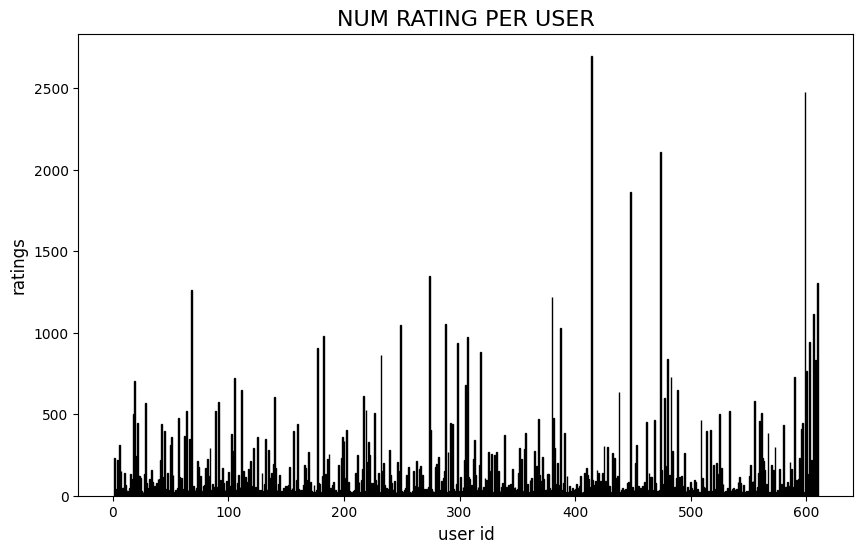

In [56]:
import matplotlib.pyplot as plt

num_rating_per_user = ratings.groupby('userId')["rating"].count().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(num_rating_per_user['userId'], num_rating_per_user['rating'], color='skyblue', edgecolor='black')

plt.title('NUM RATING PER USER', fontsize=16)
plt.xlabel('user id', fontsize=12)
plt.ylabel('ratings', fontsize=12)


plt.show()


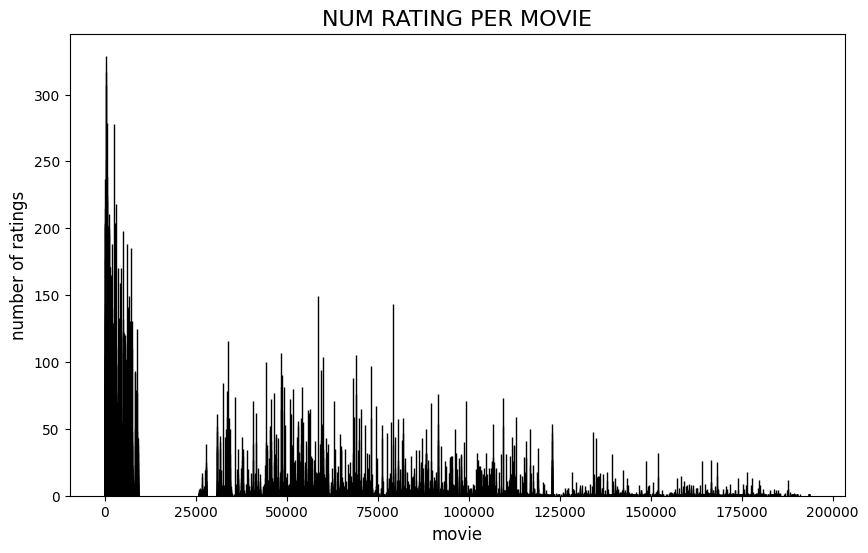

In [57]:
import matplotlib.pyplot as plt

num_rating_per_user = ratings.groupby('movieId')["rating"].count().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(num_rating_per_user['movieId'], num_rating_per_user['rating'], color='skyblue', edgecolor='black')

plt.title('NUM RATING PER MOVIE', fontsize=16)
plt.xlabel('movie', fontsize=12)
plt.ylabel('number of ratings', fontsize=12)


plt.show()


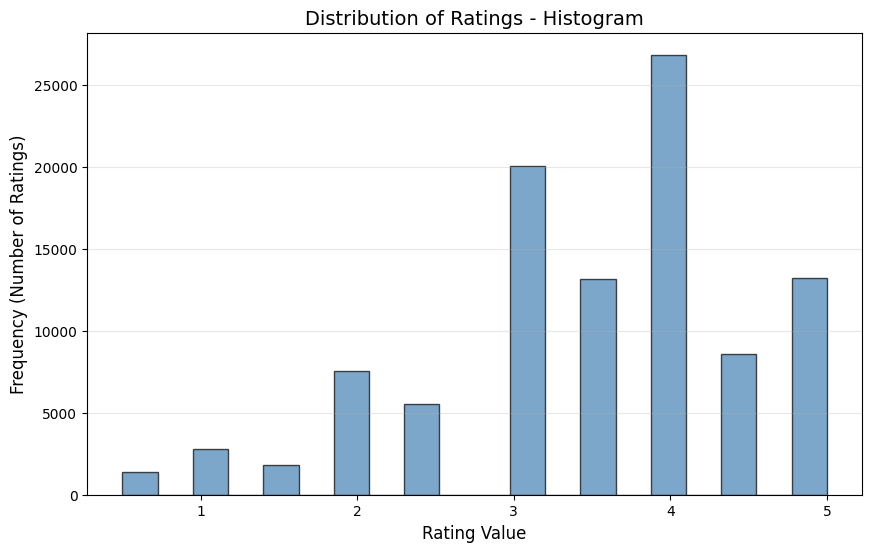

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(ratings['rating'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Rating Value', fontsize=12)
plt.ylabel('Frequency (Number of Ratings)', fontsize=12)
plt.title('Distribution of Ratings - Histogram', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [80]:
top_movie_ids = ratings[ratings["rating"] == 5]['movieId'].unique()
top_genres = movies[movies['movieId'].isin(top_movie_ids)]["genres"].dropna()
genres = []
for item in top_genres:
    genre = item.split('|')
    genres.extend(genre)
    
genres = list(set(genres))
genres

['Adventure',
 'Crime',
 'War',
 'Comedy',
 'Animation',
 'Children',
 'Western',
 'Film-Noir',
 'Thriller',
 'Action',
 'Romance',
 'Drama',
 'Horror',
 'Sci-Fi',
 '(no genres listed)',
 'Documentary',
 'IMAX',
 'Musical',
 'Fantasy',
 'Mystery']